In [1]:
# Configuration
import os
import sys

os.environ["KERAS_BACKEND"] = "jax"
sys.path.append("..")

In [2]:
# Setup
from importlib import import_module

import numpy as np
from keras import ops
from rich.console import Console
from rich.table import Table

from src.models import (
    GradientBoostedDecisionTree,
    LearnableCutFlowParallel,
    LearnableCutFlowSequential,
    MultiLayerPerceptron,
)
from src.utils import load_model, show_record_dataset, show_record_dataset_correlation

In [3]:
# Parameters
experiment_id = "4.4"

# Dataset
dataset_name = "mock4"
n_samples = 200000
seed = 42

# Model
centers = [-2, -1.8, -1.4]
n_epochs = 200
batch_size = 512

# Figure
bins = np.linspace(-10, 10, 101)
feature_names = ["x1", "x9", "x10"]
feature_names_latex = ["$x_1$", "$x_9$", "$x_{10}$"]

x_train.shape=(100000, 3)
y_train.shape=(100000, 1)
x_test.shape=(100000, 3)
y_test.shape=(100000, 1)


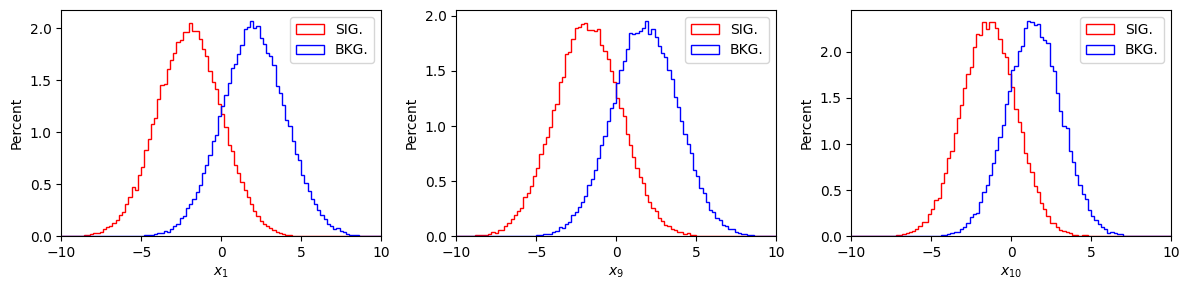

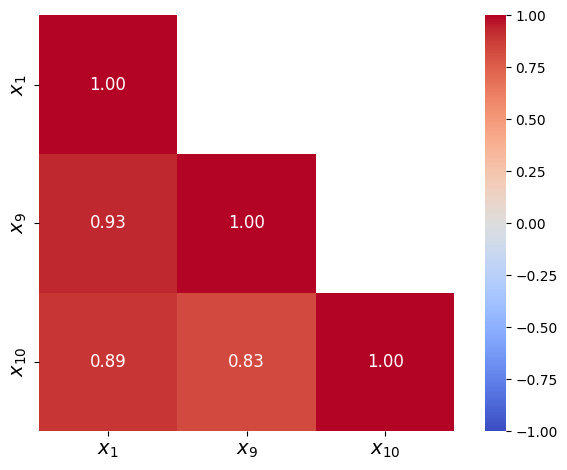

In [ ]:
# Dataset
load_data = import_module(f"src.datasets.{dataset_name}").load_data
(x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

# Figure: feature distribution
show_record_dataset(x_train, y_train, bins, feature_names_latex)

# Figure: feature correlation
show_record_dataset_correlation(x_train, feature_names_latex)

In [5]:
# Model: gradient boosted decision tree
bdt = GradientBoostedDecisionTree(input_shape=x_train.shape, name="bdt")

bdt.compile(optimizer="adam", loss="crossentropy")
bdt.fit(x_train, y_train.squeeze(), epochs=n_epochs, batch_size=batch_size)

bdt.save(f"checkpoints/{experiment_id}-{bdt.name}.pkl")
ckpt_bdt = load_model(f"checkpoints/{experiment_id}-{bdt.name}.pkl")

In [6]:
# Model: multi-layer perceptron
mlp = MultiLayerPerceptron(input_shape=x_train.shape, name="mlp")

mlp.layers[1].adapt(x_train)
mlp.compile(optimizer="adam", loss="crossentropy")
mlp.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

mlp.save(f"checkpoints/{experiment_id}-{mlp.name}.keras")
ckpt_mlp = load_model(f"checkpoints/{experiment_id}-{mlp.name}.keras")

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.4767
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3572
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3571
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3554
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3561
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3570
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3521
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3582
Epoch 9/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3566
Epoch 10/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3575
Epoch 11/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3549
Epoch 12/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3576
Epoch 13/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3564
Epoch 14/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3565
Epoch 15/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 

In [7]:
# Model: learnable cut flow parallel
lcf_par = LearnableCutFlowParallel(
    x_train.shape,
    centers,
    feature_names=feature_names,
    name="lcf_par",
)

lcf_par.normalization.adapt(x_train)
lcf_par.compile(optimizer="adam", loss="crossentropy")
lcf_par.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

lcf_par.save(f"checkpoints/{experiment_id}-{lcf_par.name}.keras")
ckpt_lcf_par = load_model(f"checkpoints/{experiment_id}-{lcf_par.name}.keras")

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3374
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3108
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - loss: 0.2914
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2779
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2677
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2617
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2569
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2543
Epoch 9/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2519
Epoch 10/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2486
Epoch 11/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2455
Epoch 12/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2433 
Epoch 13/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2410
Epoch 14/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2385  
Epoch 15/200
196/196 ━━━━━━━━━━━━━━━━

In [8]:
# Model: learnable cut flow sequential
lcf_seq = LearnableCutFlowSequential(
    x_train.shape,
    centers,
    feature_names=feature_names,
    name="lcf_seq",
)

lcf_seq.normalization.adapt(x_train)
lcf_seq.compile(optimizer="adam", loss="crossentropy")
lcf_seq.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

lcf_seq.save(f"checkpoints/{experiment_id}-{lcf_seq.name}.keras")
ckpt_lcf_seq = load_model(f"checkpoints/{experiment_id}-{lcf_seq.name}.keras")

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1031
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1100
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1137
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1170
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1200
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1209
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1228
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1236
Epoch 9/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1242
Epoch 10/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1249
Epoch 11/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1255
Epoch 12/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1250
Epoch 13/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1255
Epoch 14/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1255
Epoch 15/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 

In [9]:
# Analysis: metrics
results = []
y_true = y_test

console = Console(force_jupyter=False)
table = Table(title="Model Performance Comparison")
table.add_column("#", justify="center", style="cyan", no_wrap=True)
table.add_column("Model", style="magenta")
table.add_column("TP", justify="right", style="green")
table.add_column("FP", justify="right", style="red")
table.add_column("Accuracy", justify="right", style="blue")
table.add_column("Precision", justify="right", style="blue")
table.add_column("Significance", justify="right", style="yellow")

for i, model in enumerate([bdt, mlp, lcf_par, lcf_seq]):
    y_pred = model.predict(x_test, batch_size=batch_size, verbose=0)
    y_pred = ops.all(y_pred > 0.5, axis=1, keepdims=True)

    tp = ops.sum((y_true == 1) & (y_pred == 1))
    fp = ops.sum((y_true == 0) & (y_pred == 1))
    tn = ops.sum((y_true == 0) & (y_pred == 0))
    fn = ops.sum((y_true == 1) & (y_pred == 0))

    n_preds_true = ops.add(tp, tn)
    n_preds_false = ops.add(fp, fn)
    n_positives = ops.add(tp, fp)
    n_samples = ops.add(n_preds_true, n_preds_false)

    accuracy = ops.divide(n_preds_true, n_samples)
    precision = ops.divide(tp, n_positives)
    significance = ops.divide(tp, ops.sqrt(fp))

    table.add_row(
        str(i + 1),
        model.name,
        f"{tp:.0f}",
        f"{fp:.0f}",
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{significance:.4f}",
    )

console.print(table)

                    Model Performance Comparison                    
┏━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ # ┃ Model   ┃    TP ┃   FP ┃ Accuracy ┃ Precision ┃ Significance ┃
┡━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ 1 │ bdt     │ 41686 │ 7871 │   0.8396 │    0.8412 │     469.8674 │
│ 2 │ mlp     │ 41741 │ 7957 │   0.8393 │    0.8399 │     467.9378 │
│ 3 │ lcf_par │ 35046 │ 4725 │   0.8046 │    0.8812 │     509.8443 │
│ 4 │ lcf_seq │ 41885 │ 8033 │   0.8399 │    0.8391 │     467.3257 │
└───┴─────────┴───────┴──────┴──────────┴───────────┴──────────────┘
